In [17]:
import numpy as np
import pandas as pd
import json
import io
import math
from abc import abstractmethod
from collections import deque
from typing import List, Tuple, Dict
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState
from enum import IntEnum
from statistics import NormalDist
from typing import Any, TypeAlias
from collections import defaultdict
import matplotlib.pyplot as plt
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
# import ace_tools as tools

JSON: TypeAlias = dict[str, "JSON"] | list["JSON"] | str | int | float | bool | None

In [18]:
market_data = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R1\round-1-island-data-bottle\prices_round_1_day_0.csv", sep=";", header=0)
trade_history = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R1\round-1-island-data-bottle\trades_round_1_day_0.csv", sep=";", header=0)

In [ ]:

product = 'RAINFOREST_RESIN'
product = 'KELP'
product = 'SQUID_INK'

In [20]:
market_orders = trade_history[(trade_history['buyer']!="SUBMISSION") & (trade_history['seller']!="SUBMISSION") & (trade_history['symbol']==product)]
market = market_data[market_data['product']==product]

market_orders.loc[:, 'timestamp'] /= 100
market.loc[:, 'timestamp'] /= 100

In [21]:
market['spread'] = market['ask_price_1'] - market['bid_price_1']

def weighted_avg_price(prices, volumes):
    prices = np.array(prices, dtype=np.float64)
    volumes = np.array(volumes, dtype=np.float64)
    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    if np.sum(volumes[mask]) == 0:
        return np.nan
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

market['weighted_bid'] = market.apply(lambda row: weighted_avg_price(
    [row['bid_price_1'], row['bid_price_2'], row['bid_price_3']],
    [row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']]
), axis=1)
market['weighted_ask'] = market.apply(lambda row: weighted_avg_price(
    [row['ask_price_1'], row['ask_price_2'], row['ask_price_3']],
    [row['ask_volume_1'], row['ask_volume_2'], row['ask_volume_3']]
), axis=1)
market['weighted_mid'] = (market['weighted_bid'] + market['weighted_ask']) / 2
market['weighted_spread'] = -(market['weighted_bid'] - market['weighted_ask'])

market['change'] = np.abs(market['mid_price'].shift(1) - market['mid_price'])

C:\Users\Can\AppData\Local\Temp\ipykernel_24524\1900274271.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market['spread'] = market['ask_price_1'] - market['bid_price_1']
C:\Users\Can\AppData\Local\Temp\ipykernel_24524\1900274271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market['weighted_bid'] = market.apply(lambda row: weighted_avg_price(
C:\Users\Can\AppData\Local\Temp\ipykernel_24524\1900274271.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [22]:
market

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,weighted_bid,weighted_ask,weighted_mid,weighted_spread,change
2,0,0,SQUID_INK,1968,30,NaN,NaN,NaN,NaN,1971,...,NaN,NaN,1969.5,0.0,3,1968.000000,1971.000000,1969.500000,3.000000,NaN
3,0,1,SQUID_INK,1969,4,1967.0,31.0,NaN,NaN,1971,...,NaN,NaN,1970.0,0.0,2,1967.228571,1971.000000,1969.114286,3.771429,0.5
6,0,2,SQUID_INK,1966,1,1965.0,21.0,NaN,NaN,1969,...,NaN,NaN,1967.5,0.0,3,1965.045455,1969.000000,1967.022727,3.954545,2.5
9,0,3,SQUID_INK,1965,25,NaN,NaN,NaN,NaN,1968,...,NaN,NaN,1966.5,0.0,3,1965.000000,1968.000000,1966.500000,3.000000,1.0
14,0,4,SQUID_INK,1966,25,NaN,NaN,NaN,NaN,1968,...,NaN,NaN,1967.0,0.0,2,1966.000000,1968.806452,1967.403226,2.806452,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29986,0,9995,SQUID_INK,1830,28,NaN,NaN,NaN,NaN,1833,...,NaN,NaN,1831.5,0.0,3,1830.000000,1833.000000,1831.500000,3.000000,1.0
29989,0,9996,SQUID_INK,1832,7,1831.0,29.0,NaN,NaN,1834,...,NaN,NaN,1833.0,0.0,2,1831.194444,1834.931034,1833.062739,3.736590,1.5
29993,0,9997,SQUID_INK,1834,1,1832.0,26.0,NaN,NaN,1835,...,NaN,NaN,1834.5,0.0,1,1832.074074,1835.000000,1833.537037,2.925926,1.5
29994,0,9998,SQUID_INK,1837,27,NaN,NaN,NaN,NaN,1839,...,NaN,NaN,1838.0,0.0,2,1837.000000,1839.964286,1838.482143,2.964286,3.5


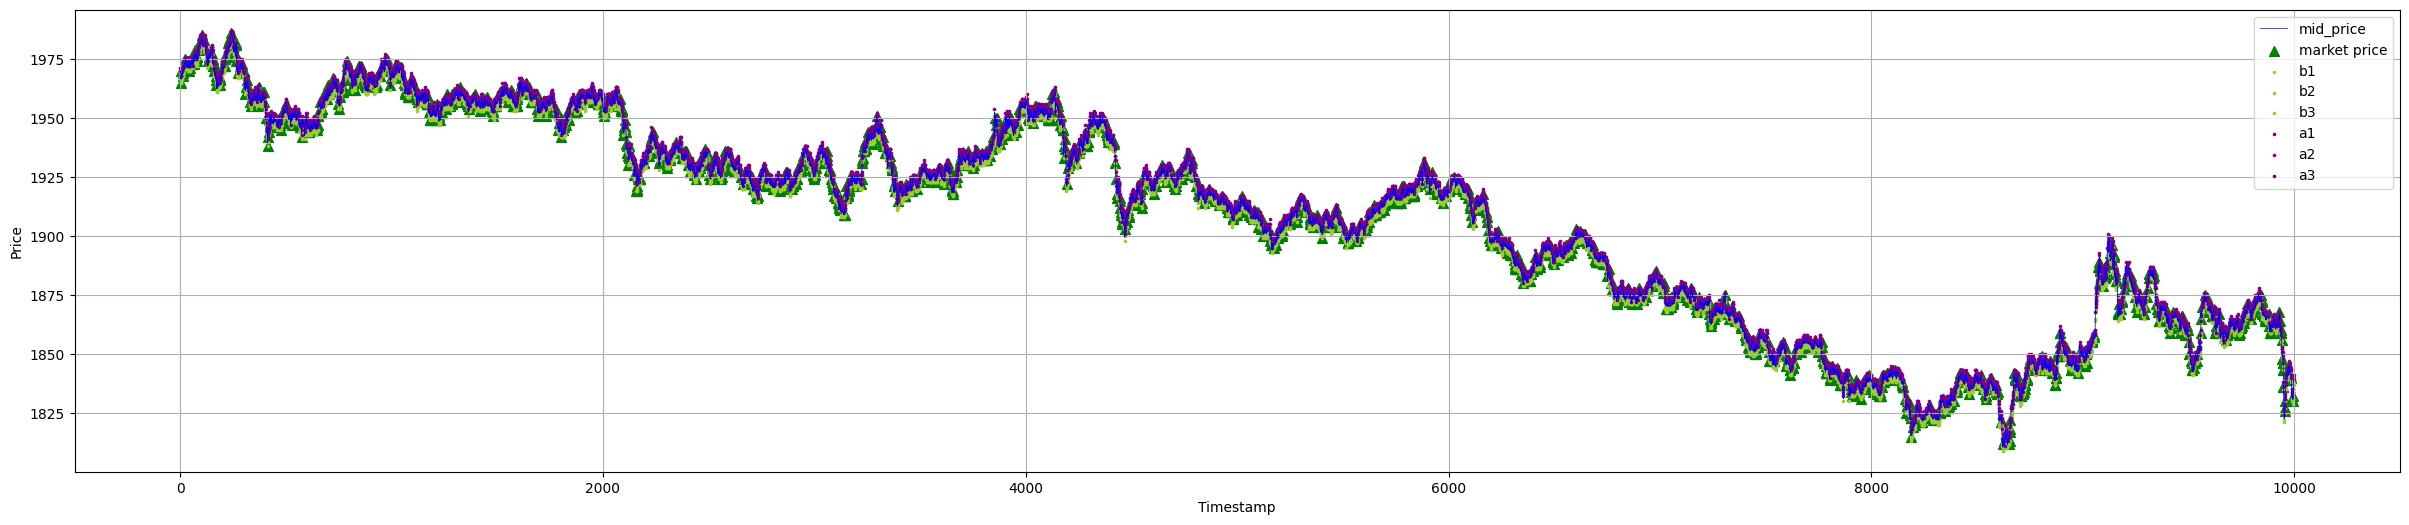

In [23]:
plt.figure(figsize=(30, 6))

plt.plot(market['timestamp'], market['mid_price'], label='mid_price', color='blue', linewidth=0.5)
plt.scatter(market_orders['timestamp'], market_orders['price'], label='market price', color='green', s=50, marker='^')

# plt.scatter(buy_df['timestamp'], buy_df['price'], label='buy LO', color='orange', s=40, marker='.')
# plt.scatter(sell_df['timestamp'], sell_df['price'], label='sell LO', color='green', s=40, marker='.')

plt.scatter(market['timestamp'], market['bid_price_1'], label='b1', color='yellowgreen', s=10, marker='.')
plt.scatter(market['timestamp'], market['bid_price_2'], label='b2', color='yellowgreen', s=10, marker='.')
plt.scatter(market['timestamp'], market['bid_price_3'], label='b3', color='yellowgreen', s=10, marker='.')

plt.scatter(market['timestamp'], market['ask_price_1'], label='a1', color='purple', s=10, marker='.')
plt.scatter(market['timestamp'], market['ask_price_2'], label='a2', color='purple', s=10, marker='.')
plt.scatter(market['timestamp'], market['ask_price_3'], label='a3', color='purple', s=10, marker='.')

plt.xlabel('Timestamp')
plt.ylabel('Price')
# plt.gca().yaxis.set_major_locator(MultipleLocator(1)) # 间隔设为1，只显示整数
plt.legend()
plt.grid(True)
# plt.xlim(0, 500)
# plt.ylim(1925, 1975)
plt.show()

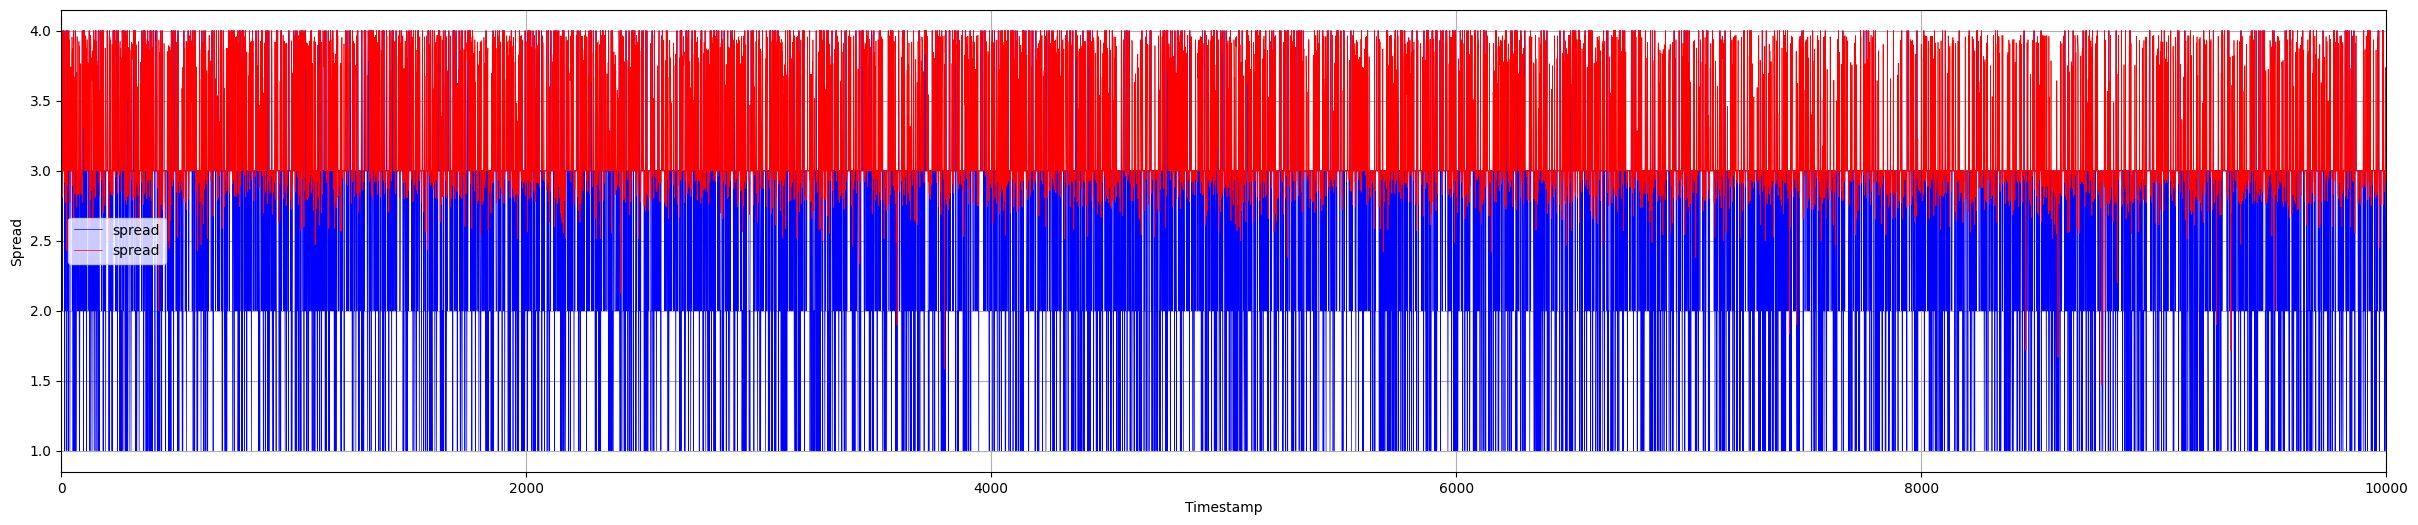

In [24]:
plt.figure(figsize=(30, 6))

plt.plot(market['timestamp'], market['spread'], label='spread', color='blue', linewidth=0.5)
plt.plot(market['timestamp'], market['weighted_spread'], label='spread', color='red', linewidth=0.5)
plt.xlabel('Timestamp')
plt.ylabel('Spread')
# plt.gca().yaxis.set_major_locator(MultipleLocator(1)) # 间隔设为1，只显示整数
plt.legend()
plt.grid(True)
plt.xlim(0,10000)
# plt.ylim(1925, 1975)
plt.show()

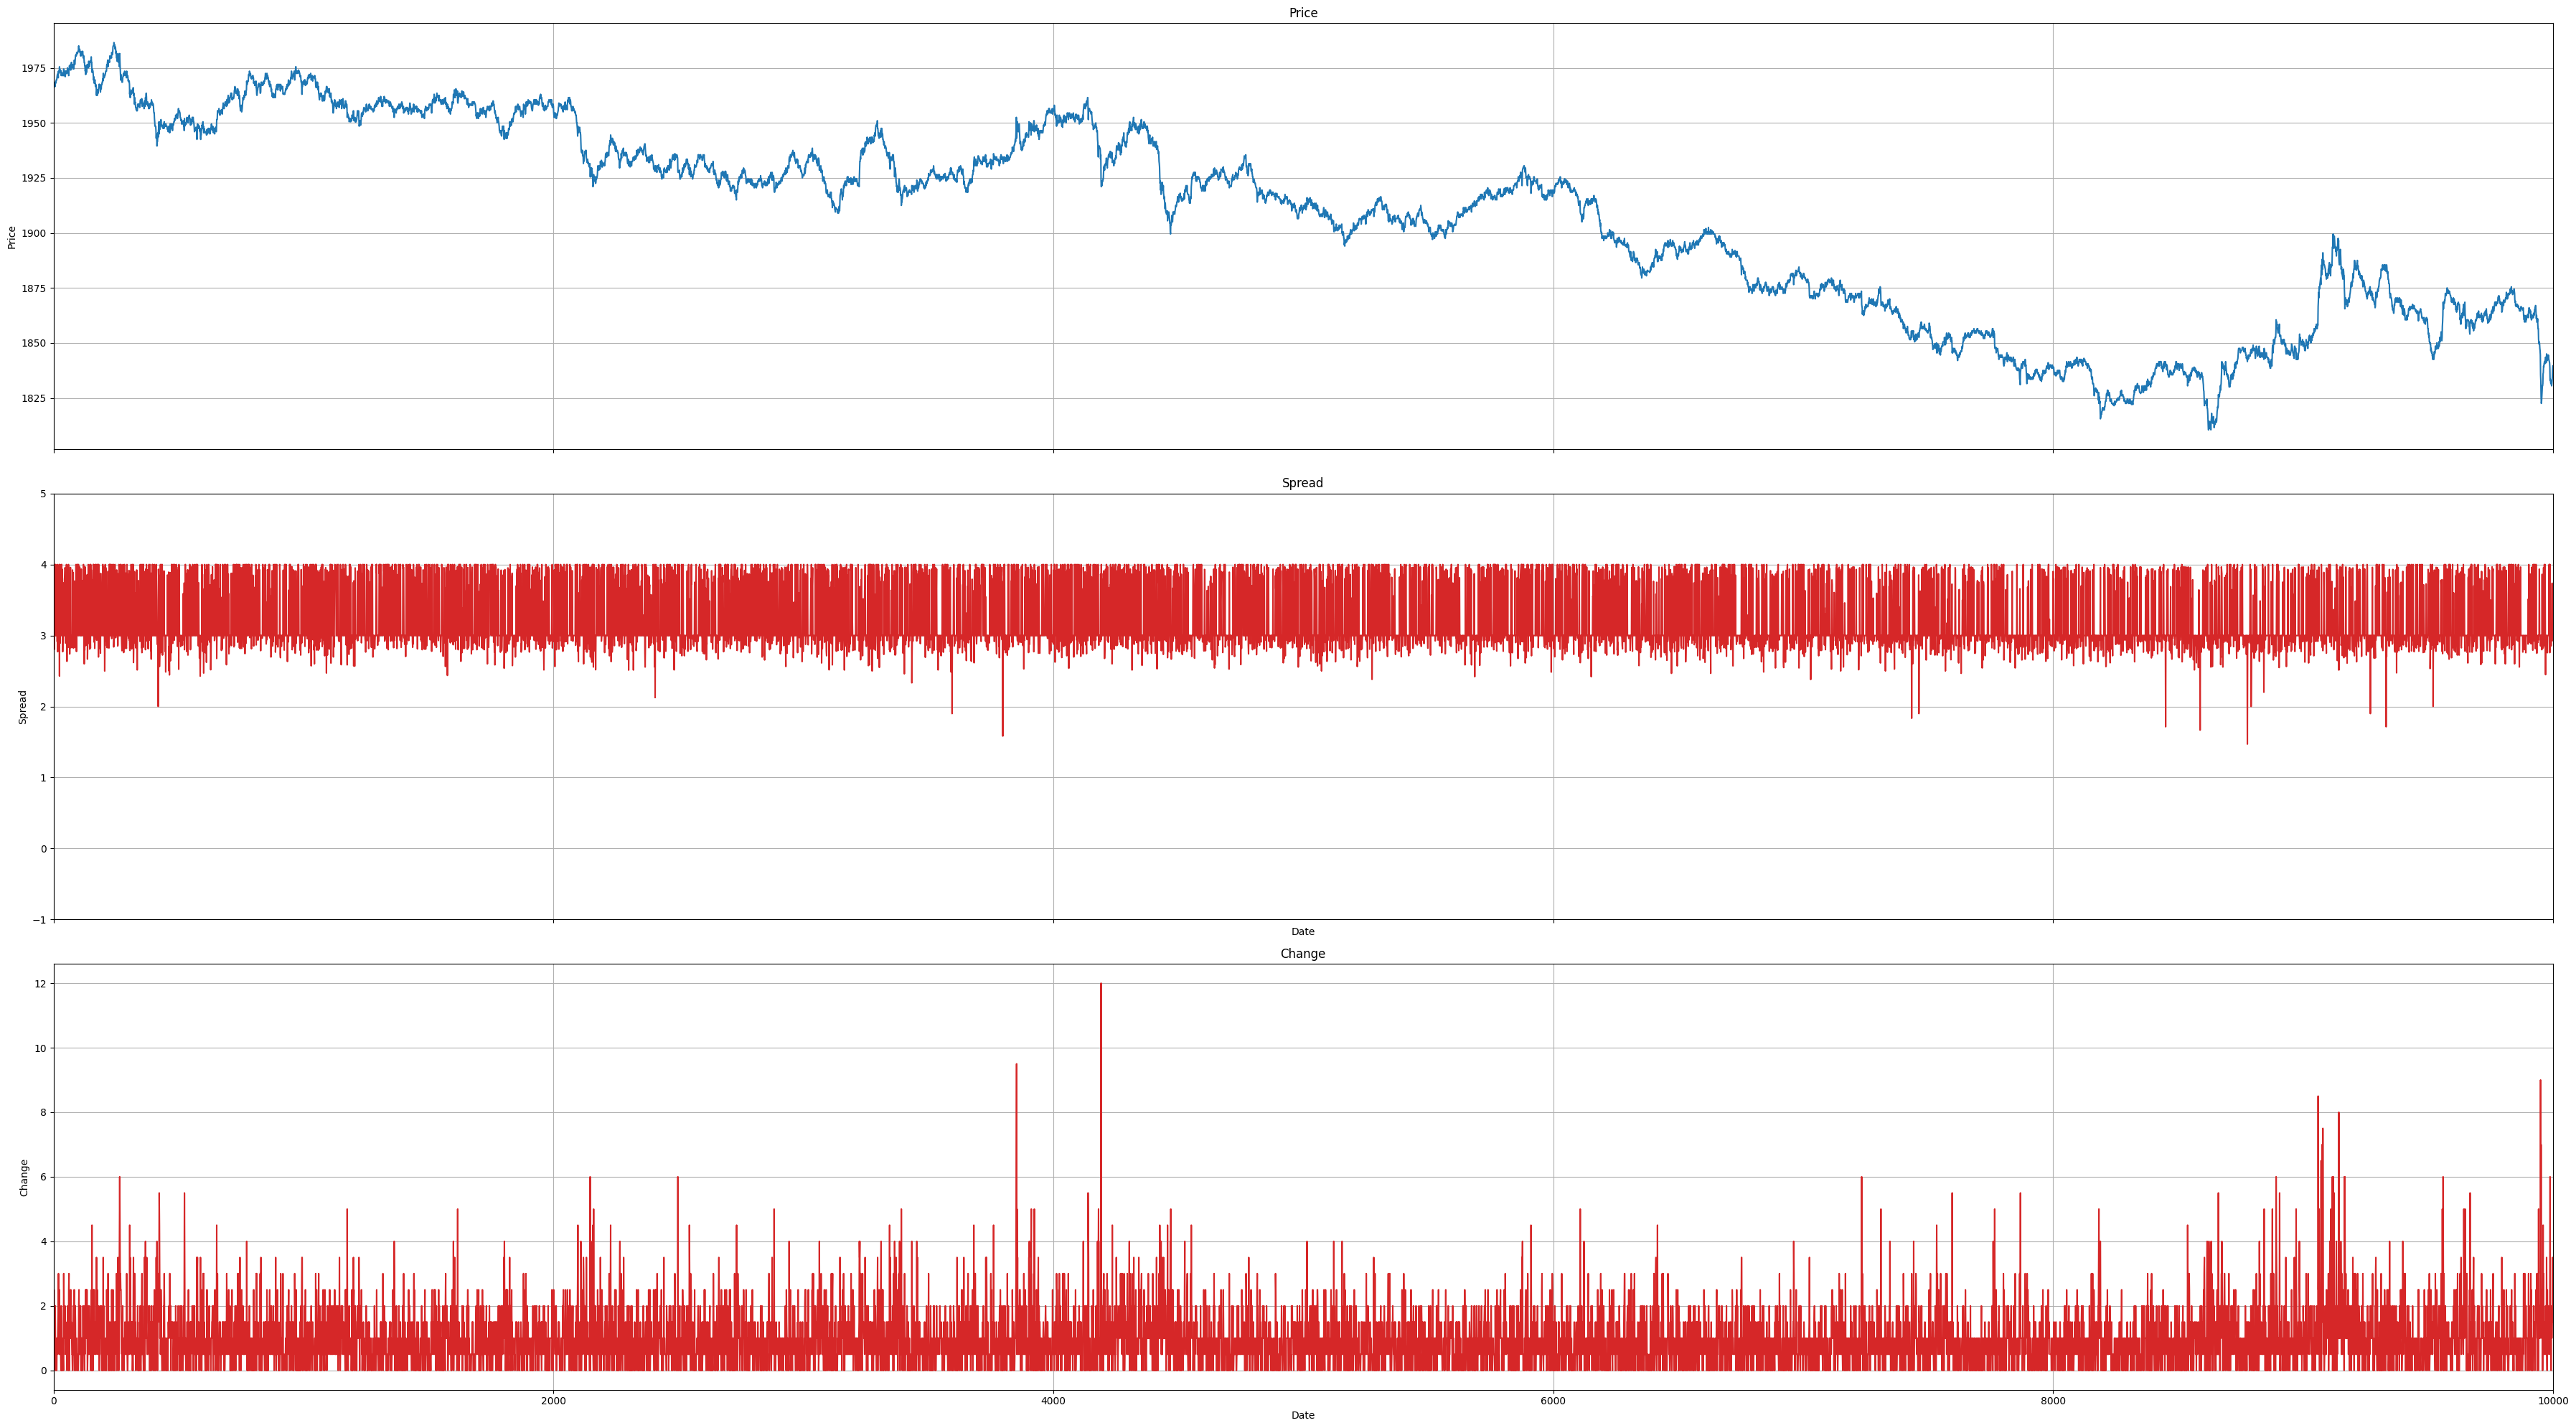

In [25]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(36, 20), sharex=True)

# 上图：画价格走势
ax1.plot(market['timestamp'], market['mid_price'], color='tab:blue', label='Price')
ax1.set_ylabel('Price')
ax1.set_title('Price')
ax1.grid(True)

# 下图：画 spread
ax2.plot(market['timestamp'], market['weighted_spread'], color='tab:red', label='Spread')
ax2.set_xlabel('Date')
ax2.set_ylabel('Spread')
ax2.set_title('Spread')
ax2.grid(True)
ax2.set_ylim(2-3, 2+3)

ax3.plot(market['timestamp'], market['change'], color='tab:red', label='Spread')
ax3.set_xlabel('Date')
ax3.set_ylabel('Change')
ax3.set_title('Change')
ax3.grid(True)

# 统一布局
plt.xlim(0, 10000)
plt.tight_layout()
plt.show()

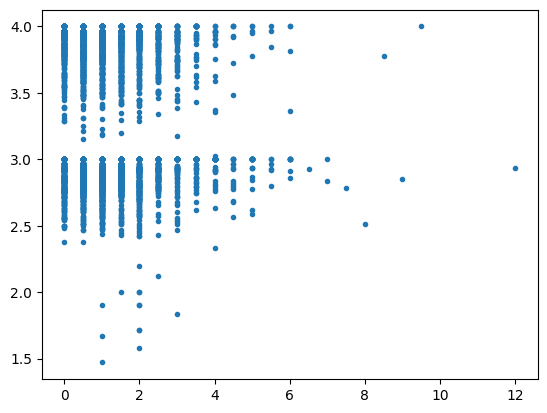

In [26]:
plt.scatter(market.change,market.weighted_spread, marker='.')

In [27]:
trade_history[(trade_history['symbol'] == product)]

,timestamp,buyer,seller,symbol,currency,price,quantity
4,300,NaN,NaN,SQUID_INK,SEASHELLS,1965.0,6
8,500,NaN,NaN,SQUID_INK,SEASHELLS,1970.0,1
10,1300,NaN,NaN,SQUID_INK,SEASHELLS,1970.0,2
11,1300,NaN,NaN,SQUID_INK,SEASHELLS,1968.0,5
13,1400,NaN,NaN,SQUID_INK,SEASHELLS,1969.0,1
...,...,...,...,...,...,...,...
8171,998500,NaN,NaN,SQUID_INK,SEASHELLS,1840.0,10
8173,998700,NaN,NaN,SQUID_INK,SEASHELLS,1840.0,1
8176,998800,NaN,NaN,SQUID_INK,SEASHELLS,1831.0,1
8179,999500,NaN,NaN,SQUID_INK,SEASHELLS,1830.0,2


In [28]:
# def weighted_avg_price(prices, volumes):
#     mask = ~np.isnan(prices) & ~np.isnan(volumes)
#     if mask.sum() == 0:
#         return np.nan
#     return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# # 计算加权买价（前三档）
# market_data['weighted_bid'] = market_data.apply(lambda row: weighted_avg_price(
#     np.array([row['bid_price_1'], row['bid_price_2'], row['bid_price_3']]),
#     np.array([row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']])
# ), axis=1)

In [29]:
# market = market_data[market_data['product'] == 'STARFRUIT']
# def weighted_avg_price(prices, volumes):
#     prices = np.array(prices, dtype=np.float64)
#     volumes = np.array(volumes, dtype=np.float64)
#     mask = ~np.isnan(prices) & ~np.isnan(volumes)
    
#     if np.sum(volumes[mask]) == 0:
#         return np.nan
    
#     return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# # 假设你的 DataFrame 是 df
# market['weighted_bid'] = market.apply(lambda row: weighted_avg_price(
#     [row['bid_price_1'], row['bid_price_2'], row['bid_price_3']],
#     [row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']]
# ), axis=1)

# market['weighted_ask'] = market.apply(lambda row: weighted_avg_price(
#     [row['ask_price_1'], row['ask_price_2'], row['ask_price_3']],
#     [row['ask_volume_1'], row['ask_volume_2'], row['ask_volume_3']]
# ), axis=1)


# # 最终的加权中间价（加权 bid + 加权 ask）/ 2
# market['weighted_mid'] = (market['weighted_bid'] + market['weighted_ask']) / 2

In [30]:
# def full_book_weighted_price(row):
#     prices = [
#         row.get('bid_price_1'), row.get('bid_price_2'), row.get('bid_price_3'),
#         row.get('ask_price_1'), row.get('ask_price_2'), row.get('ask_price_3')
#     ]
#     volumes = [
#         row.get('bid_volume_1'), row.get('bid_volume_2'), row.get('bid_volume_3'),
#         row.get('ask_volume_1'), row.get('ask_volume_2'), row.get('ask_volume_3')
#     ]

#     prices = np.array(prices, dtype=np.float64)
#     volumes = np.array(volumes, dtype=np.float64)

#     mask = ~np.isnan(prices) & ~np.isnan(volumes)
#     if np.sum(volumes[mask]) == 0:
#         return np.nan
    
#     return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# market['book_weighted_price'] = market.apply(full_book_weighted_price, axis=1)